# Week 1 — Feature-Family Ablation (Lindsey-only, Path A)

**Goal.** For each (family-configuration × classifier × experiment), measure recall/precision/F1. Output a single results table + heatmap.

**Families (3, derived from the 62 Lindsey features):**
- **L-content** — content-sensitive scoring dimensions (political, attack, emotional, low_effort, authenticity)
- **L-structural** — language-agnostic structural dimensions (emoji, length, repetition, punctuation, caps)
- **L-coordination** — coordination signals + engagement + temporal (coordination, algorithmic dimensions + composites + engagement + delta_* temporal features)

**Configurations (7):** each family alone (3) + leave-one-out (3) + full (1) = 7.

**Total runs:** 3 experiments × 7 configurations × 5 classifiers = **105 runs.**

**Inputs:** `phase2_{train,test}_exp{1,2,3}.csv` (produced by `phase2_all_experiments.ipynb`).

**Outputs:**
- `week1_ablation_results.csv` — long-form (experiment × config × classifier × recall/precision/f1)
- `week1_ablation_heatmap.png` — F1 heatmap (config × classifier), one panel per experiment
- `week1_ablation_pivot.csv` — wide pivot for thesis table

## Cell 1 — Imports and family definitions

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.naive_bayes    import MultinomialNB
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import LinearSVC
from sklearn.tree           import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── Family definitions ──────────────────────────────────────────────────────
# 12 Lindsey dimensions in 3 groups
CONTENT_DIMS    = ['political', 'attack', 'emotional', 'low_effort', 'authenticity']
STRUCTURAL_DIMS = ['emoji', 'length', 'repetition', 'punctuation', 'caps']
COORD_DIMS      = ['coordination', 'algorithmic']

# Each dim spawns 4 aggregation features (_mean, _max, _std, _sum)
AGGS = ['mean', 'max', 'std', 'sum']
def expand(dims):
    return [f'{d}_{a}' for d in dims for a in AGGS]

# Composites + engagement + temporal split:
# - The 4 composite/global score columns belong with "coordination/engagement" (they aggregate across all dims)
COMPOSITE_COLS = ['overall_max', 'overall_mean', 'n_high_score', 'n_med_score']
ENGAGEMENT_COLS = ['n_comments', 'n_threads', 'likes_total', 'likes_per_comment',
                   'threads_per_comment', 'likes_mean', 'replies_mean']
TEMPORAL_COLS  = ['delta_mean_s', 'delta_std_s', 'delta_min_s']

FAMILIES = {
    'L-content':      expand(CONTENT_DIMS),
    'L-structural':   expand(STRUCTURAL_DIMS),
    'L-coordination': expand(COORD_DIMS) + COMPOSITE_COLS + ENGAGEMENT_COLS + TEMPORAL_COLS,
}

# Sanity check
total_features = sum(len(v) for v in FAMILIES.values())
print(f'Family feature counts:')
for k, v in FAMILIES.items():
    print(f'  {k:18s} {len(v):3d} features')
print(f'  {"TOTAL":18s} {total_features:3d}  (expect 62)')
assert total_features == 62, 'Family partition does not cover all 62 features'

# ── Configurations: 7 per experiment ────────────────────────────────────────
CONFIGS = {
    'only_content':       ['L-content'],
    'only_structural':    ['L-structural'],
    'only_coordination':  ['L-coordination'],
    'drop_content':       ['L-structural', 'L-coordination'],
    'drop_structural':    ['L-content', 'L-coordination'],
    'drop_coordination':  ['L-content', 'L-structural'],
    'full':               ['L-content', 'L-structural', 'L-coordination'],
}
print(f'\nConfigurations: {len(CONFIGS)} ({list(CONFIGS.keys())})')


2026-05-24 13:36:16.759669: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-24 13:36:16.762582: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-24 13:36:16.802586: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-24 13:36:21.092535: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-24 13:36:30.962054: W tensorflow/compiler/

Family feature counts:
  L-content           20 features
  L-structural        20 features
  L-coordination      22 features
  TOTAL               62  (expect 62)

Configurations: 7 (['only_content', 'only_structural', 'only_coordination', 'drop_content', 'drop_structural', 'drop_coordination', 'full'])


## Cell 2 — Data loader and classifier suite

In [2]:
def load_exp(exp_id):
    tr = pd.read_csv(f'phase2_train_exp{exp_id}.csv')
    te = pd.read_csv(f'phase2_test_exp{exp_id}.csv')
    return tr, te

def select_features(df, config_families):
    """Return feature matrix using only columns from the listed families."""
    cols = []
    for fam in config_families:
        cols.extend(FAMILIES[fam])
    # Filter to columns actually present (defensive against schema drift)
    cols = [c for c in cols if c in df.columns]
    return df[cols].values, cols

def metrics(y_true, y_pred):
    return {
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }

def fit_predict_all(Xtr, ytr, Xte):
    out = {}

    # NB
    mm = MinMaxScaler().fit(Xtr)
    Xtr_mm, Xte_mm = mm.transform(Xtr), mm.transform(Xte)
    nb = MultinomialNB(alpha=1.0).fit(Xtr_mm, ytr)
    out['NB'] = nb.predict(Xte_mm)

    # RF
    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
    out['RF'] = rf.predict(Xte)

    # SVM linear
    svm = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000).fit(Xtr, ytr)
    out['SVM'] = svm.predict(Xte)

    # DNN (CPU)
    ss = StandardScaler().fit(Xtr)
    Xtr_ss, Xte_ss = ss.transform(Xtr), ss.transform(Xte)
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    dnn = Sequential([
        Input(shape=(Xtr_ss.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid'),
    ])
    dnn.compile(optimizer=SGD(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    dnn.fit(Xtr_ss, ytr, epochs=200, batch_size=16, verbose=0)
    out['DNN'] = (dnn.predict(Xte_ss, verbose=0).ravel() >= 0.5).astype(int)

    # DT with grid search
    n_splits = min(5, max(2, int(ytr.sum())))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    dt_grid = {'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10]}
    dt_gs = GridSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        dt_grid, scoring='f1', cv=skf, n_jobs=-1
    ).fit(Xtr, ytr)
    out['DT'] = dt_gs.predict(Xte)

    return out

print('Helpers ready')


Helpers ready


## Cell 3 — Run the ablation grid (105 runs)

In [3]:
rows = []
t0 = time.time()
total = 3 * len(CONFIGS) * 5
done  = 0

for exp_id in (1, 2, 3):
    tr, te = load_exp(exp_id)
    ytr = tr['label'].values
    yte = te['label'].values

    for cfg_name, fams in CONFIGS.items():
        Xtr, used_cols = select_features(tr, fams)
        Xte, _         = select_features(te, fams)

        preds = fit_predict_all(Xtr, ytr, Xte)
        for clf, ypred in preds.items():
            m = metrics(yte, ypred)
            rows.append({
                'experiment':   exp_id,
                'config':       cfg_name,
                'n_features':   Xtr.shape[1],
                'classifier':   clf,
                **m,
            })
            done += 1

        elapsed = time.time() - t0
        eta = (elapsed / done) * (total - done) if done else 0
        print(f'[{done:3d}/{total}]  exp{exp_id}  {cfg_name:20s} '
              f'({Xtr.shape[1]:2d}f)  elapsed={elapsed:5.1f}s  eta={eta:5.1f}s')

results = pd.DataFrame(rows)
results.to_csv('week1_ablation_results.csv', index=False)
print(f'\n✅ {len(results)} rows → week1_ablation_results.csv')


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
2026-05-24 13:36:45.088706: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-05-24 13:36:45.088743: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: idea-26
2026-05-24 13:36:45.088750: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: idea-26
2026-05-24 13:36:45.088880: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.c

[  5/105]  exp1  only_content         (20f)  elapsed=  5.4s  eta=107.5s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


[ 10/105]  exp1  only_structural      (20f)  elapsed=  6.7s  eta= 63.5s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


...

[ 95/105]  exp3  drop_structural      (42f)  elapsed= 36.9s  eta=  3.9s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[100/105]  exp3  drop_coordination    (40f)  elapsed= 39.1s  eta=  2.0s


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[105/105]  exp3  full                 (62f)  elapsed= 41.3s  eta=  0.0s

✅ 105 rows → week1_ablation_results.csv


## Cell 4 — Wide pivot table for thesis

In [4]:
CONFIG_ORDER = ['only_content', 'only_structural', 'only_coordination',
                 'drop_content', 'drop_structural', 'drop_coordination', 'full']
CLF_ORDER    = ['NB', 'RF', 'SVM', 'DNN', 'DT']

pivot_f1 = results.pivot_table(
    index=['experiment', 'config'],
    columns='classifier',
    values='f1',
).reindex(CLF_ORDER, axis=1)

# Reorder rows by experiment then by CONFIG_ORDER
pivot_f1 = pivot_f1.reindex(
    [(e, c) for e in (1, 2, 3) for c in CONFIG_ORDER]
).round(4)

pivot_f1.to_csv('week1_ablation_pivot.csv')
print('Wide pivot (F1) → week1_ablation_pivot.csv')
print(pivot_f1.to_string())


Wide pivot (F1) → week1_ablation_pivot.csv
classifier                        NB      RF     SVM     DNN      DT
experiment config                                                   
1          only_content       0.1333  0.6718  0.6891  0.0721  0.6617
           only_structural    0.1322  0.6578  0.6435  0.6330  0.6525
           only_coordination  0.6774  0.2667  0.3902  0.6186  0.3143
           drop_content       0.6486  0.2069  0.2443  0.5744  0.2406
           drop_structural    0.6891  0.2645  0.4000  0.6100  0.3077
           drop_coordination  0.2462  0.6348  0.6527  0.6124  0.6798
           full               0.6507  0.2149  0.2443  0.5946  0.1719
2          only_content       0.1000  0.6907  0.6802  0.6667  0.6768
           only_structural    0.2424  0.6816  0.7016  0.6893  0.6782
           only_coordination  0.6845  0.3600  0.2642  0.6875  0.2772
           drop_content       0.6885  0.3400  0.3750  0.6303  0.2913
           drop_structural    0.6957  0.3191  0.2569  0.6707

## Cell 5 — F1 heatmap (config × classifier, one panel per experiment)

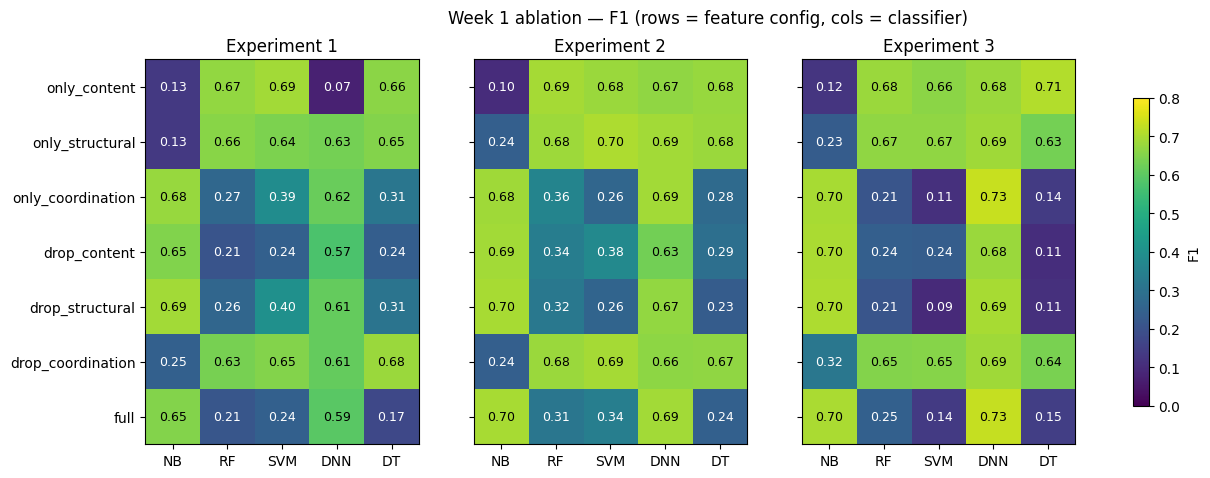

→ week1_ablation_heatmap.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

vmin, vmax = 0.0, max(0.8, results['f1'].max() * 1.05)

for ax, exp_id in zip(axes, (1, 2, 3)):
    sub = results[results['experiment'] == exp_id]
    mat = sub.pivot(index='config', columns='classifier', values='f1')
    mat = mat.reindex(CONFIG_ORDER).reindex(columns=CLF_ORDER)

    im = ax.imshow(mat.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(CLF_ORDER)))
    ax.set_xticklabels(CLF_ORDER)
    ax.set_yticks(range(len(CONFIG_ORDER)))
    ax.set_yticklabels(CONFIG_ORDER)
    ax.set_title(f'Experiment {exp_id}')

    # Cell annotations
    for i in range(len(CONFIG_ORDER)):
        for j in range(len(CLF_ORDER)):
            v = mat.values[i, j]
            ax.text(j, i, f'{v:.2f}',
                    ha='center', va='center',
                    color='white' if v < vmax * 0.55 else 'black',
                    fontsize=9)

fig.suptitle('Week 1 ablation — F1 (rows = feature config, cols = classifier)', fontsize=12)
fig.colorbar(im, ax=axes, shrink=0.8, label='F1')
plt.savefig('week1_ablation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ week1_ablation_heatmap.png')


## Cell 6 — Quick interpretation helpers

In [6]:
# 1. Which single family is the strongest, per (experiment, classifier)?
singles = results[results['config'].str.startswith('only_')]
best_single = (
    singles.loc[singles.groupby(['experiment','classifier'])['f1'].idxmax(),
                ['experiment','classifier','config','f1']]
           .reset_index(drop=True)
)
print('Best single-family per (experiment × classifier):')
print(best_single.to_string(index=False))

# 2. Drop-one impact: full F1 minus drop_X F1 (positive = family matters)
full    = results[results['config'] == 'full'].set_index(['experiment','classifier'])['f1']
drops   = (results[results['config'].str.startswith('drop_')]
           .pivot_table(index=['experiment','classifier'], columns='config', values='f1'))
delta   = drops.rsub(full, axis=0).rename(columns=lambda c: c.replace('drop_', 'remove_'))
print('\nDrop-one impact (positive ⇒ that family contributed; negative ⇒ removing it helped):')
print(delta.round(4).to_string())

# 3. Highlight DT-on-Exp3 (the known failure mode) — does any config rescue it?
dt_e3 = results[(results['experiment'] == 3) & (results['classifier'] == 'DT')] \
        .sort_values('f1', ascending=False)[['config','n_features','f1','precision','recall']]
print('\nDT on Exp 3 — does any feature config avoid all-zero?')
print(dt_e3.to_string(index=False))


Best single-family per (experiment × classifier):
 experiment classifier            config       f1
          1        DNN   only_structural 0.633028
          1         DT      only_content 0.661654
          1         NB only_coordination 0.677419
          1         RF      only_content 0.671815
          1        SVM      only_content 0.689139
          2        DNN   only_structural 0.689266
          2         DT   only_structural 0.678161
          2         NB only_coordination 0.684492
          2         RF      only_content 0.690722
          2        SVM   only_structural 0.701571
          3        DNN only_coordination 0.733945
          3         DT      only_content 0.706897
          3         NB only_coordination 0.695652
          3         RF      only_content 0.678571
          3        SVM   only_structural 0.666667

Drop-one impact (positive ⇒ that family contributed; negative ⇒ removing it helped):
config                 remove_content  remove_coordination  remo

## Done

Three deliverables produced:
- `week1_ablation_results.csv` — raw long-form results (105 rows)
- `week1_ablation_pivot.csv` — thesis-ready wide pivot
- `week1_ablation_heatmap.png` — 3-panel F1 heatmap

Cell 6 prints three diagnostic summaries that you'll want to look at first:
1. Best single family per (experiment, classifier) — tells you where the signal lives
2. Drop-one impact — tells you which families are doing real work vs being redundant
3. DT-on-Exp 3 across configs — checks whether the all-zero collapse is feature-driven or classifier-driven

Whatever the numbers show, **it's a Week 1 finding** — don't pivot.

Estimated runtime: ~10–20 minutes total (the DT GridSearch is the slowest piece; everything else is fast on this size of data).